# Validation against SST data

Contains comparision of model output and ODYSSEA satellite data of sea surface temperature by calculating metrics, as well as vizualing data and bias.

In [ ]:
from pathlib import Path
import sys
import os

# Project root
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from modules import metrics
from modules import read_files as read
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import xarray as xr
import glob
import h5py
import copernicusmarine

### Configuration

In [2]:
run_name = 'validation'                                                  # set run name for output
output_file = '../../results/validation/SST/SST_metrics.xlsx'            # output file name of metrics

output_folder_api = Path("../../data/ODYSSEA")                           # folder for downloaded file from API
output_folder_api.mkdir(parents=True, exist_ok=True)    
dir_odyssea = '../../data/ODYSSEA/odyssea_validation.nc'                 # directory to file 

dir_model = '../../data/model_output/L1/WaterProperties_validation.hdf5' # directory to model output data
outdir_model = '../../data/model_output/L1//'                            # directory for converted files

### Download ODYSSEA satellite data from  API

In [5]:
copernicusmarine.subset(
    dataset_id="IFREMER-ATL-SST-L4-NRT-OBS_FULL_TIME_SERIE",
    variables=["analysed_sst"],
    minimum_longitude=-17.17,
    maximum_longitude=-16.75,
    minimum_latitude=27.99,
    maximum_latitude=28.41,
    start_datetime="2023-04-13T00:00:00",
    end_datetime="2023-05-31T00:00:00",
    output_directory=str(output_folder_api),
    output_filename="odyssea_validation.nc"
)


INFO - 2026-08-26T11:09:43Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:Copernicus Marine password:

INFO - 2026-08-26T11:10:10Z - Selected dataset version: "201904"
INFO - 2026-08-26T11:10:10Z - Selected dataset part: "default"
INFO - 2026-08-26T11:10:15Z - Starting download. Please wait...
100%|██████████| 2/2 [00:01<00:00,  1.74it/s]
INFO - 2026-08-26T11:10:16Z - Successfully downloaded to ..\..\data\ODYSSEA\odyssea_validation.nc


ResponseSubset(file_path=WindowsPath('../../data/ODYSSEA/odyssea_validation.nc'), output_directory=WindowsPath('../../data/ODYSSEA'), filename='odyssea_validation.nc', file_size=0.05825954198473282, data_transfer_size=13.851358778625954, variables=['analysed_sst'], coordinates_extent=[GeographicalExtent(minimum=-17.170000076293945, maximum=-16.75, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=27.989999771118164, maximum=28.40999984741211, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2023-04-13T00:00:00+00:00', maximum='2023-05-31T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED')

### Read data and convert model output files to netcdf

In [3]:
# read satellite data
ds_odyssea = xr.open_dataset(dir_odyssea)
ds_odyssea['sst'] = ds_odyssea['analysed_sst'] - 273.15  # convert to celcius degrees
ds_odyssea

<xarray.Dataset> Size: 380kB
Dimensions:       (time: 49, latitude: 22, longitude: 22)
Coordinates:
  * time          (time) datetime64[ns] 392B 2023-04-13 ... 2023-05-31
  * latitude      (latitude) float32 88B 27.99 28.01 28.03 ... 28.37 28.39 28.41
  * longitude     (longitude) float32 88B -17.17 -17.15 -17.13 ... -16.77 -16.75
Data variables:
    analysed_sst  (time, latitude, longitude) float64 190kB 293.3 ... 295.5
    sst           (time, latitude, longitude) float64 190kB 20.15 ... 22.31
Attributes:
    title:                     ODYSSEA North-East Atlantic Sea Surface Temper...
    Conventions:               CF-1.7, ACDD-1.3, ISO 8601
    institution:               Institut Francais de Recherche pour l'Exploita...
    references:                Product User Manual for L4 Odyssea Product ove...
    history:                   Optimally interpolated SST originally produced...
    contact:                   emmanuelle.autret@ifremer.fr;jfpiolle@ifremer.fr
    source:                    Odyssea L4 processor
    copernicusmarine_version:  2.0.1

In [4]:
# read and convert model output files
t, dates = read.MOHIDHdf5toNetcdf(dir_model, outdir=outdir_model)

# concat files with time

files = sorted(
    glob.glob(os.path.join(outdir_model, 'WaterProperties_*.nc'))
)
datasets = [xr.open_dataset(f) for f in files]

# Stack them along a 'time' dimension
ds_model = xr.concat(datasets, dim='time')

# Close the underlying file handles now that data is in memory
for d in datasets:
    d.close()

# assign coordinate according to dates
with h5py.File(dir_model, 'r') as f:
    time_keys = sorted(f['Time'].keys())
    real_dates = []
    for k in time_keys:
        arr = f['Time'][k][:].ravel().astype(float)  
        y, m, d, H, M, S = arr[:6]
        real_dates.append(pd.Timestamp(int(y), int(m), int(d),
                                       int(H), int(M), int(round(S))))

ds_model = ds_model.assign_coords(time=('time', real_dates))

# remove fill values
ds_model = ds_model.where(ds_model.temperature > 0, drop=True)

# average to daily
ds_model = ds_model.resample(time='1D').mean() 

# rename coordinates
ds_model = ds_model.rename({'lat':'latitude'})
ds_model = ds_model.rename({'lon':'longitude'})

# interpolate model output to satellite data
ds_model = ds_model.interp(latitude=ds_odyssea.latitude, longitude=ds_odyssea.longitude)
ds_model

<xarray.Dataset> Size: 380kB
Dimensions:      (time: 49, latitude: 22, longitude: 22)
Coordinates:
  * time         (time) datetime64[us] 392B 2023-04-13 2023-04-14 ... 2023-05-31
  * latitude     (latitude) float32 88B 27.99 28.01 28.03 ... 28.37 28.39 28.41
  * longitude    (longitude) float32 88B -17.17 -17.15 -17.13 ... -16.77 -16.75
Data variables:
    temperature  (time, latitude, longitude) float64 190kB 20.26 20.25 ... 21.77
    Bathymetry   (time, latitude, longitude) float64 190kB 937.0 ... 809.8

### Compare

In [5]:
# Calculate metrics
temp = ds_model["temperature"]
sst = ds_odyssea["sst"]

# Keep only locations where both datasets have valid values
valid = temp.notnull() & sst.notnull()
temp_valid = temp.where(valid, drop=True)
sst_valid = sst.where(valid, drop=True)

rmse = metrics.rmse(temp_valid, sst_valid).mean()
bias = metrics.bias(temp_valid, sst_valid).mean()

# Flatten both DataArrays into 1D arrays
a = temp_valid.values.flatten()
b = sst_valid.values.flatten()

# Keep only valid paired values
mask = np.isfinite(a) & np.isfinite(b)

a = a[mask]
b = b[mask]

# Pearson correlation
pearson_value = metrics.pearson_r(a,b)

print('RMSE:', rmse.item())
print('BIAS:', bias.item())
print("pearson_correlation:", pearson_value)

RMSE: 0.43227255884079924
BIAS: -0.2989031618896445
pearson_correlation: 0.779680799780581


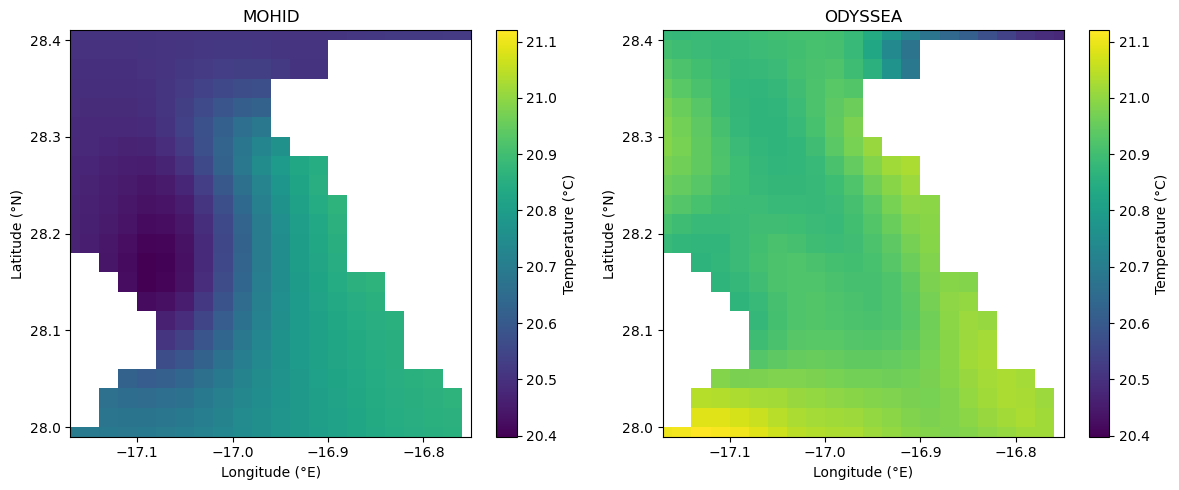

In [6]:
# visualize mean

temp_mean = temp_valid.mean(dim="time")
sst_mean = sst_valid.mean(dim="time")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# make sure color limits are same
vmin = min(
    temp_mean.min().item(),
    sst_mean.where(valid).min().item()
)
vmax = max(
    temp_mean.where(valid).max().item(),
    sst_mean.where(valid).max().item()
)
lat_min = min(temp_mean['latitude'].min(),sst_mean['latitude'].min()).item()
lat_max = max(temp_mean['latitude'].max(),sst_mean['latitude'].max()).item()
lon_min = min(temp_mean['longitude'].min(),sst_mean['longitude'].min()).item()
lon_max = max(temp_mean['longitude'].max(),sst_mean['longitude'].max()).item()

temp_mean.plot(
    ax=axes[0],
   vmin=vmin,
   vmax=vmax,
    cbar_kwargs={'label': 'Temperature (°C)'}
)
axes[0].set_title(f'MOHID')


sst_mean.plot(
    ax=axes[1],
    vmin=vmin,
    vmax=vmax,
    cbar_kwargs={'label': 'Temperature (°C)'}
)
axes[1].set_title(f'ODYSSEA')

# Common axis settings
for ax in axes:
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.xaxis.set_major_locator(MultipleLocator(0.1))  # every 2° longitude
    ax.yaxis.set_major_locator(MultipleLocator(0.1))  # every 2° latitude
    ax.tick_params(axis='y', labelleft=True)

plt.tight_layout()

# Save figure
plt.savefig(f'../../results/validation/SST/SST_comparison_{run_name}.png', dpi=300, bbox_inches="tight")

plt.show()

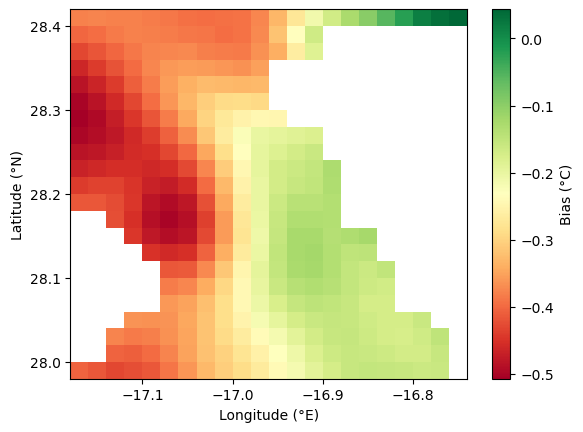

In [17]:
# visualize bias
bias_area = metrics.bias(temp_valid, sst_valid)

vminb = bias_area.min().item()
vmaxb = bias_area.max().item()

fig, ax = plt.subplots(1)

bias_area.plot(
    cmap="RdYlGn",  
    cbar_kwargs={'label': 'Bias (°C)'},
    vmin=vminb,
    vmax=vmaxb)


ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.xaxis.set_major_locator(MultipleLocator(0.1))  # every 2° longitude
ax.yaxis.set_major_locator(MultipleLocator(0.1))  # every 2° latitude

plt.savefig(f'../../results/validation/SST/BIAS_{run_name}.png', dpi=300, bbox_inches="tight")

plt.show()

### Export results of metrics and display results

In [18]:
# create dataframe for this run
new_row = pd.DataFrame({
    "Run": [run_name],
    "RMSE (°C)": [rmse.item()],
    "BIAS (°C)": [bias.item()],
    "Pearson Correlation": [pearson_value]
})

# append to existing Excel file, or create
if os.path.exists(output_file):
    existing = pd.read_excel(output_file)
    # Add the new run
    results = pd.concat([existing, new_row], ignore_index=True)
else:
    results = new_row

# Save the updated table
results.to_excel(output_file, index=False)

print(f"Saved results for {run_name} to {output_file}")

Saved results for validation to ../../results/validation/SST/SST_metrics.xlsx


In [19]:
# Display results
results_all = pd.read_excel(output_file)

results_all

,Run,RMSE (°C),BIAS (°C),Pearson Correlation
0,validation,0.432273,-0.298903,0.779681
